In [2]:
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException
from obspy import UTCDateTime
from obspy import read_inventory
from obspy import read
from obspy.signal import util
import obspy.core.stream as st
import obspy.signal.cross_correlation as cc
import obspy.signal.filter as flt
import obspy.signal.trigger as trg
import obspy.signal.freqattributes as frq
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt
import scipy.interpolate as pol
import scipy.fftpack as fftpack
from scipy import stats
import math
import gc

Hello
('whitesmoke', 'gainsboro', 'lightgray', 'lightgrey', 'silver', 'darkgray', 'darkgrey', 'gray', 'grey', 'dimgray', 'dimgrey', 'black')
Year: 2014
Year: 2015
Year: 2016
Year: 2017
Year: 2018
Year: 2019
Year: 2020
Year: 2021
Year: 2022
Year: 2023
Year: 2024
Year: 2025
Total count: 71155


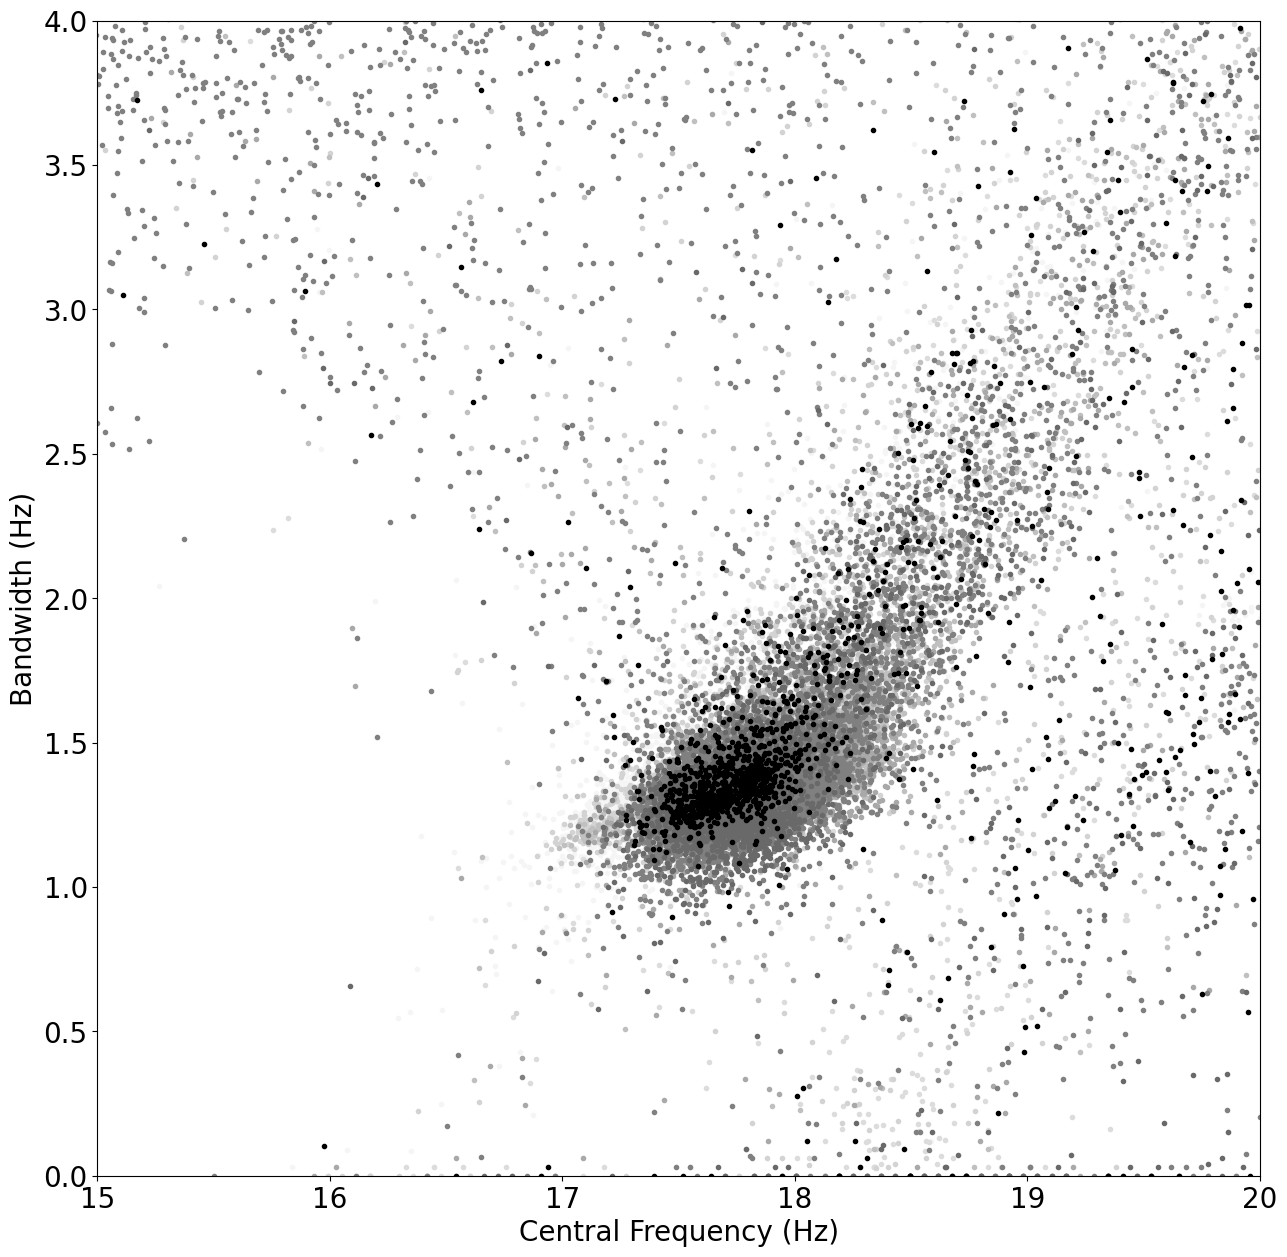

In [11]:
#
# A type of detections
#
#
ntwo =180
path_npy="Jupyter/NPY/"
path_png="Jupyter/PNG/"
ts1="-10-10 00:00:00"
#
print("Hello")
col=('whitesmoke','gainsboro','lightgray','lightgrey','silver','darkgray','darkgrey','gray','grey','dimgray','dimgrey','black')
k = 0
count = 0
print(col)
fig, ax = plt.subplots(figsize=(15, 15), )
for year in ("2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025"):
    print("Year:",year)
    ts = year+ts1
    timest = ts.replace(':','-')
    timestring = timest.replace(' ','-')
    dets = np.load(path_npy+"DetTime_"+timestring+"_"+str(ntwo)+".npy")
    cfreq = np.load(path_npy+"SeasonCfreq_"+timestring+"_"+str(ntwo)+".npy")
    bwidth = np.load(path_npy+"SeasonBwidth_"+timestring+"_"+str(ntwo)+".npy")
    ctype = np.load(path_npy+"SeasonType_"+timestring+"_"+str(ntwo)+".npy")
#    print("Year:",year)
    for i in range(len(ctype)):
        if(ctype[i] == 'A'):
            count = count +1
            plt.plot(cfreq[i], bwidth[i],color=col[k],marker='.')
        if(ctype[i] == '0' and (bwidth[i] > 2. or bwidth[i] < 1.)):
            count = count +1
            plt.plot(cfreq[i], bwidth[i],color=col[k],marker='.')
    k = k+1

print("Total count:",count)
plt.xlabel('Central Frequency (Hz)', fontsize=20)
plt.ylabel('Bandwidth (Hz)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([0.,4])
plt.xlim([15,20])
plt.savefig(path_png+"Season_A_CF_BW")
plt.show()

Hello
('whitesmoke', 'gainsboro', 'lightgray', 'lightgrey', 'silver', 'darkgray', 'darkgrey', 'gray', 'grey', 'dimgray', 'dimgrey', 'black')
Year: 2014
Year: 2015
Year: 2016
Year: 2017
Year: 2018
Year: 2019
Year: 2020
Year: 2021
Year: 2022
Year: 2023
Year: 2024
Year: 2025
Total count: 77505


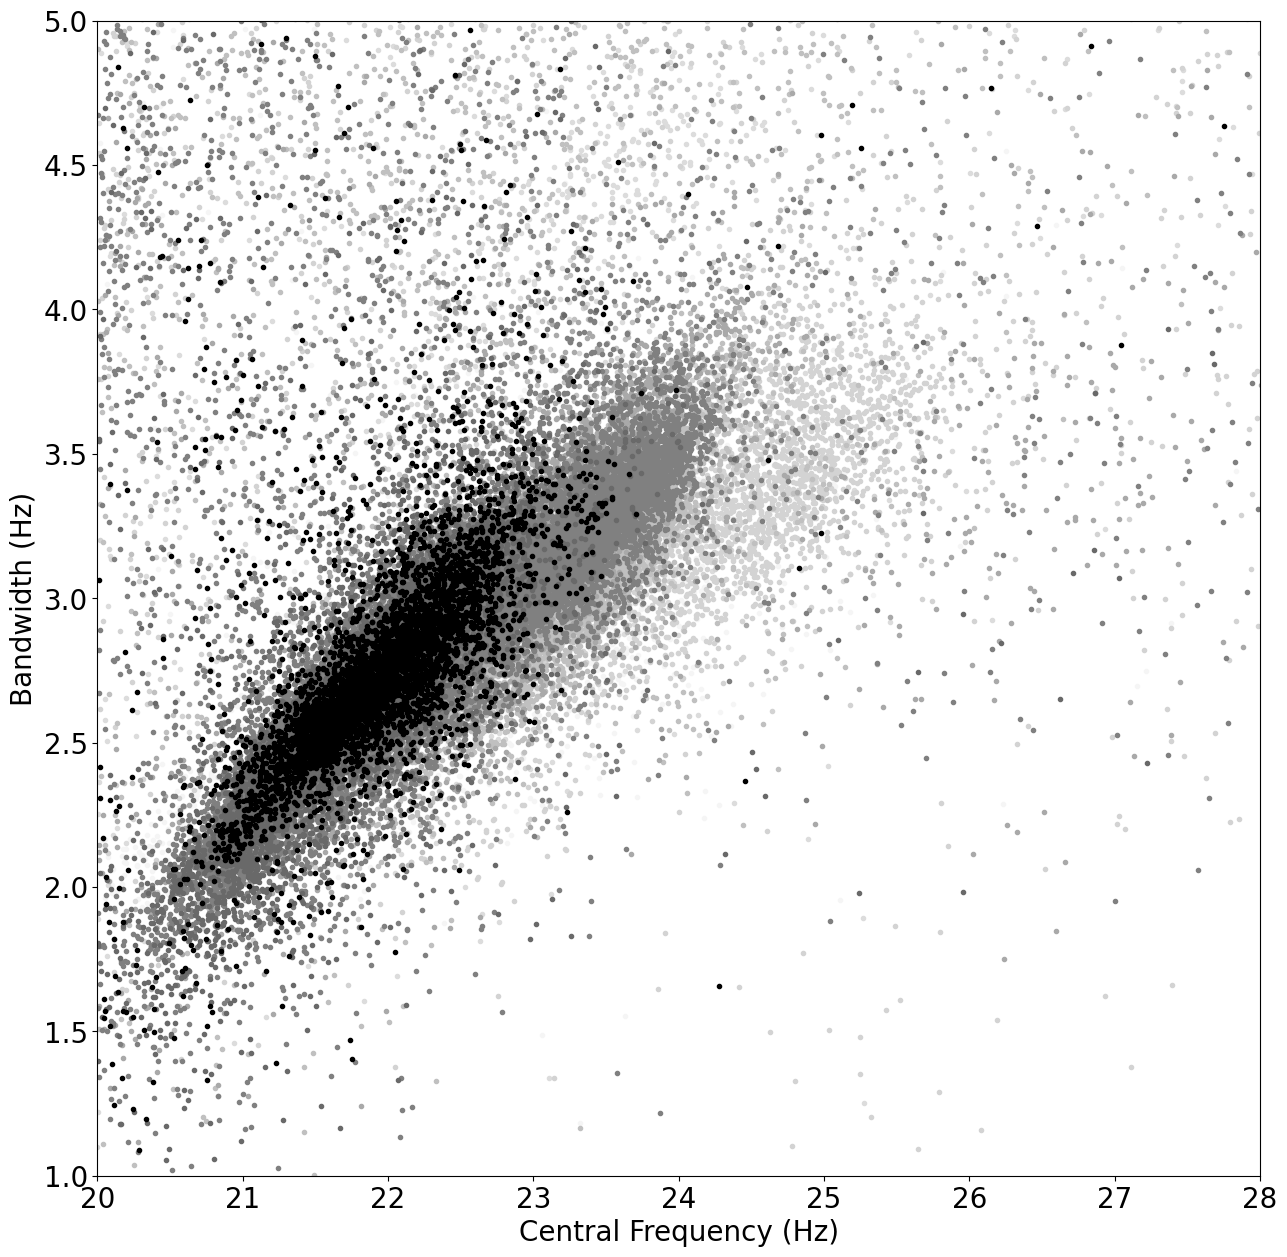

In [13]:
#
# B type of detections
#
#
ntwo =180
path_npy="Jupyter/NPY/"
path_png="Jupyter/PNG/"
ts1="-10-10 00:00:00"
#
print("Hello")
col=('whitesmoke','gainsboro','lightgray','lightgrey','silver','darkgray','darkgrey','gray','grey','dimgray','dimgrey','black')
k = 0
count = 0
print(col)
fig, ax = plt.subplots(figsize=(15, 15), )
for year in ("2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025"):
    print("Year:",year)
    ts = year+ts1
    timest = ts.replace(':','-')
    timestring = timest.replace(' ','-')
    dets = np.load(path_npy+"DetTime_"+timestring+"_"+str(ntwo)+".npy")
    cfreq = np.load(path_npy+"SeasonCfreq_"+timestring+"_"+str(ntwo)+".npy")
    bwidth = np.load(path_npy+"SeasonBwidth_"+timestring+"_"+str(ntwo)+".npy")
    ctype = np.load(path_npy+"SeasonType_"+timestring+"_"+str(ntwo)+".npy")
#    print("Year:",year)
    for i in range(len(ctype)):
        if(ctype[i] == 'B'):
            count = count +1
            plt.plot(cfreq[i], bwidth[i],color=col[k],marker='.')
        if(ctype[i] == '0' and bwidth[i] < 2.):
            count = count +1
            plt.plot(cfreq[i], bwidth[i],color=col[k],marker='.')
    k = k+1

print("Total count:",count)
plt.xlabel('Central Frequency (Hz)', fontsize=20)
plt.ylabel('Bandwidth (Hz)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([1.,5])
plt.xlim([20,28])
plt.savefig(path_png+"Season_B_CF_BW")
plt.show()

Hello
('yellow', 'orange', 'lightgreen', 'green', 'lightblue', 'cyan', 'blue', 'purple', 'red')
Year: 2017
Averages and standard deviation for B: 3722 18.6 +/- 0.32 2.3 +/- 0.27
Year: 2018
Averages and standard deviation for B: 8611 18.7 +/- 0.43 2.2 +/- 0.28
Year: 2019
Averages and standard deviation for B: 2487 18.7 +/- 0.45 2.2 +/- 0.33
Year: 2020
Averages and standard deviation for B: 5839 18.7 +/- 0.43 2.2 +/- 0.33
Year: 2021
Averages and standard deviation for B: 9504 18.8 +/- 0.5 2.1 +/- 0.32
Year: 2022
Averages and standard deviation for B: 18651 18.8 +/- 0.68 2.1 +/- 0.33
Year: 2023
Averages and standard deviation for B: 4673 18.9 +/- 0.84 2.0 +/- 0.35
Year: 2024
Averages and standard deviation for B: 5670 19.0 +/- 0.85 2.0 +/- 0.33
Year: 2025
Averages and standard deviation for B: 6301 19.0 +/- 0.87 2.0 +/- 0.34
Total count: 65458


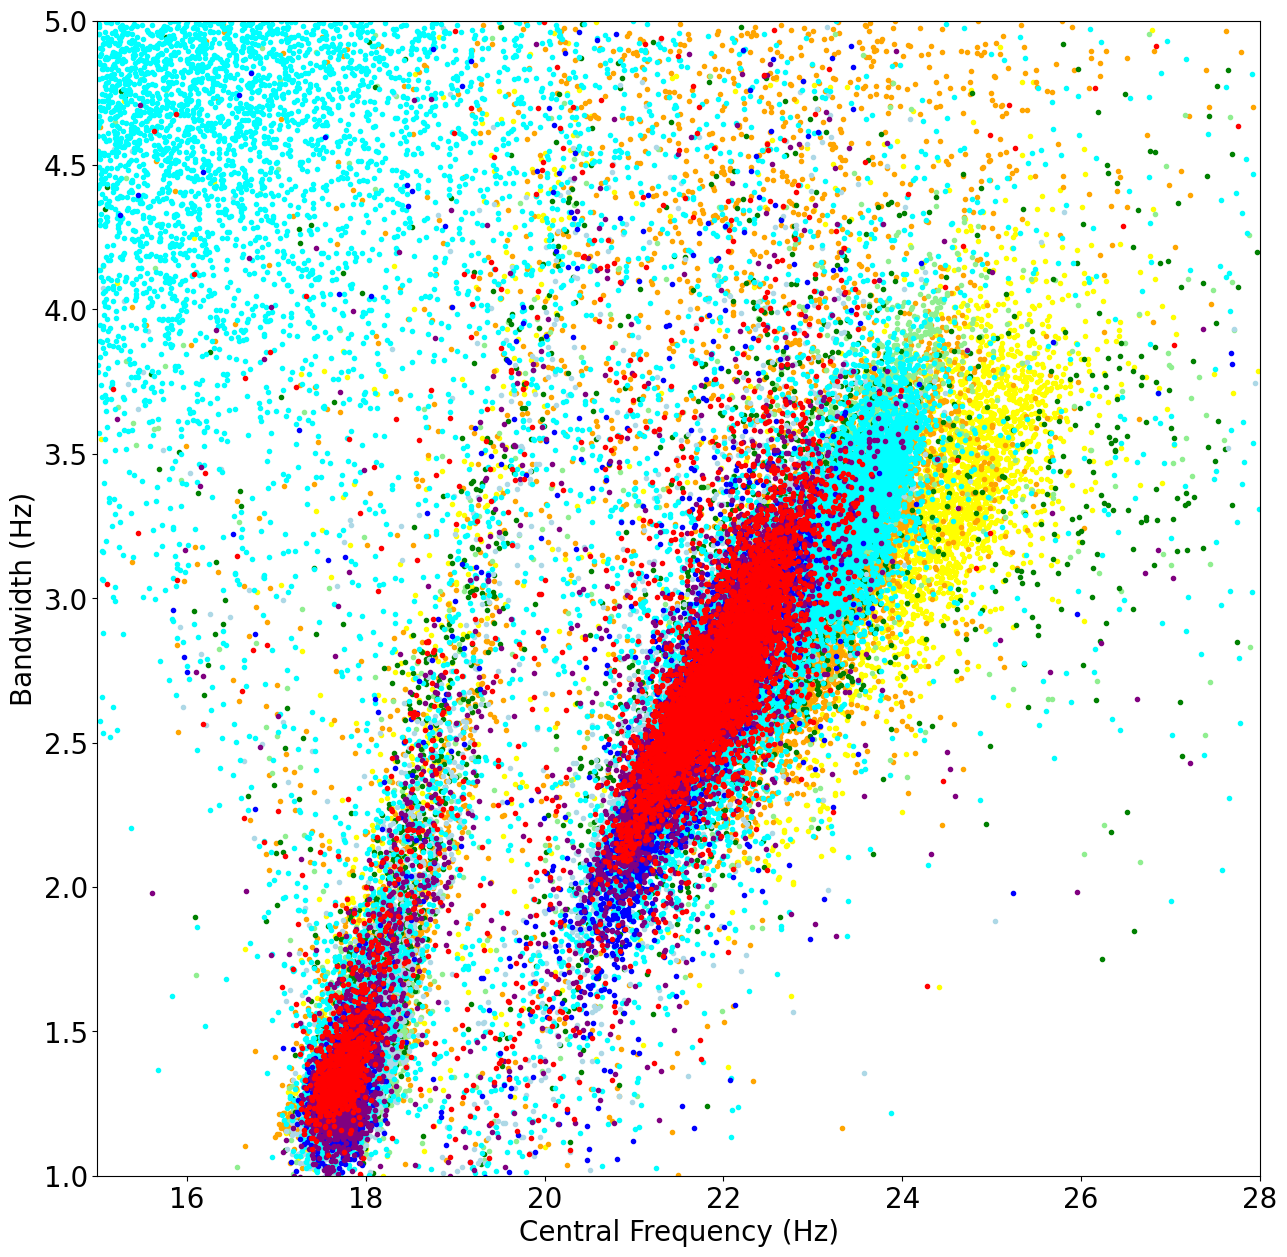

In [5]:
#
# A and B types of detections
#
#
ntwo =180
path_npy="Jupyter/NPY/"
path_png="Jupyter/PNG/"
ts1="-10-10 00:00:00"
#
print("Hello")
#col=('whitesmoke','gainsboro','lightgray','lightgrey','silver','darkgray','darkgrey','gray','grey','dimgray','dimgrey','black')
col=('yellow','orange','lightgreen','green','lightblue','cyan','blue','purple','red')
k=0
count = 0
c=np.empty(0)
b=np.empty(0)
avcfreq=0.
avbw=0.
print(col)
fig, ax = plt.subplots(figsize=(15, 15), )
#for year in ("2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025"):
for year in ("2017","2018","2019","2020","2021","2022","2023","2024","2025"):
    print("Year:",year)
    ts = year+ts1
    timest = ts.replace(':','-')
    timestring = timest.replace(' ','-')
    dets = np.load(path_npy+"DetTime_"+timestring+"_"+str(ntwo)+".npy")
    cfreq = np.load(path_npy+"SeasonCfreq_"+timestring+"_"+str(ntwo)+".npy")
    bwidth = np.load(path_npy+"SeasonBwidth_"+timestring+"_"+str(ntwo)+".npy")
    ctype = np.load(path_npy+"SeasonType_"+timestring+"_"+str(ntwo)+".npy")
#    print("Year:",year)
    ycount=0
    for i in range(len(ctype)):
        if(i == 0):
            avcfreq = cfreq[i]
            avbw = bwidth[i]
            erfreq=0.
            erbw=0.
        if(cfreq[i] > 15 and cfreq[i] < 28 and bwidth[i] < 5. and bwidth[i] > 0):
            if(ctype[i]=='0' and bwidth[i] < 3.):
                c=np.append(c,cfreq[i])
                b=np.append(b,bwidth[i])
            count = count +1
            ycount = ycount+1
            plt.plot(cfreq[i], bwidth[i],color=col[k],marker='.')
    avc=np.median(c)
    avb=np.median(b)
    stdc=stats.median_abs_deviation(c)
    stdb=stats.median_abs_deviation(b)
#   
#    plt.errorbar(avc,avb,xerr=stdc,yerr=stdb,color='black')
#    plt.plot(avc,avb,markerfacecolor=col[k],marker='D',markersize=20, markeredgecolor='black',
#                    markeredgewidth=4)
#    plt.annotate(year,(avc,avb),xytext=(avc-0.4,avb+0.01),size=15,weight='bold')
    print("Averages and standard deviation for B:",ycount,round(avc,1),"+/-",
          round(stdc,2),round(avb,1),"+/-",round(stdb,2))
    k = k+1
print("Total count:",count)
plt.xlabel('Central Frequency (Hz)', fontsize=20)
plt.ylabel('Bandwidth (Hz)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([1.,5.])
plt.xlim([15,28])
plt.savefig(path_png+"Season_AB_CF_BW")
plt.show()